In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import get_scorer_names
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from scipy.stats import randint, uniform, loguniform
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict
from sklearn.compose import make_column_selector
from sklearn import set_config
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split


import joblib

In [2]:
df_train=pd.read_csv('data/train.csv')
df_test=pd.read_csv('data/test.csv')

In [ ]:
le=LabelEncoder()

X=df_train.drop(columns=['health_condition'])
y = le.fit_transform(df_train['health_condition']) #text to numeric values
test_ids = df_test['id'].copy() #to keep the ids

In [ ]:
#feature engineering (stateless)
def features(df):
    df=df.copy()
    df=df.drop(columns='id')
    df['stress_level_NaN']=df['stress_level'].isna().astype(int)
    df['sleep_duration_NaN']=df['sleep_duration'].isna().astype(int)
    df['physical_activity_level_NaN']=df['physical_activity_level'].isna().astype(int)
    df['smoking_alcohol_NaN']=df['smoking_alcohol'].isna().astype(int)
    df['calorie_expenditure_NaN']=df['calorie_expenditure'].isna().astype(int)
    df['water_intake_NaN']=df['water_intake'].isna().astype(int)


    df['eau_normal'] = (2 - df['water_intake']).clip(lower=0)    
    df['BMI_normal'] = ((df['bmi'] > 18.5) & (df['bmi'] < 25)).astype(int)
    df['heart_normal'] = ((df['heart_rate'] > 50) & (df['heart_rate'] < 70)).astype(int)
    df['heart_dif']=abs(df['heart_rate']-60)
    df['step_dif']=(10000-df['step_count']).clip(lower=0)
    df['BMI_dif']=abs(df['bmi']-22)
    df['sleep_dif']=abs(df['sleep_duration']-8)
    df['riskscore']=((df['sleep_duration'] < 6).astype(int)+ (df['stress_level'] == 'high').astype(int)+ (df['physical_activity_level'] == 'sedentary').astype(int))

    df['calorie_dif'] = abs(df['calorie_expenditure'] - 2500)
    df['sleep_excess'] = (df['sleep_duration'] - 9).clip(lower=0)      
    df['sleep_deficit'] = (6 - df['sleep_duration']).clip(lower=0)    
    df['step_normal'] = (df['step_count'] >= 8000).astype(int)

    df['n_abnormal'] = (
        (1 - df['BMI_normal']) +
        (1 - df['heart_normal']) +
        (1 - df['step_normal']) +
        (df['sleep_deficit'] > 0).astype(int) +
        (df['eau_normal'] > 0).astype(int)
    )
    df['n_missing'] = df[[c for c in df.columns if c.endswith('_NaN')]].sum(axis=1)

    df['steps_per_calorie'] = df['step_count'] / (df['calorie_expenditure'] + 1)
    df['activity_vs_calories'] = df['calorie_expenditure'] / (df['step_count'] + 1)
    df['hr_per_activity'] = df['heart_rate'] / (df['step_count'] + 1) 
    df['bmi_x_sedentary'] = df['BMI_dif'] * (df['physical_activity_level'] == 'sedentary').astype(int)

    df['riskscore_plus'] = (
        (df['sleep_duration'] < 6).astype(int) +
        (df['sleep_duration'] > 9).astype(int) +
        (df['stress_level'] == 'high').astype(int) +
        (df['physical_activity_level'] == 'sedentary').astype(int) +
        (df['bmi'] > 30).astype(int) * 2 +
        (df['bmi'] < 18.5).astype(int) +
        (df['step_count'] < 5000).astype(int) +
        (df['heart_rate'] > 90).astype(int)
    )

    df['bmi_cat'] = pd.cut(df['bmi'], [0, 18.5, 25, 30, 100], labels=False)
    df['hr_cat'] = pd.cut(df['heart_rate'], [0, 60, 100, 300], labels=False)
    df['sleep_cat'] = pd.cut(df['sleep_duration'], [0, 6, 9, 24], labels=False)

    df['stress_x_sleep_deficit'] = (df['stress_level'] == 'high').astype(int) * df['sleep_deficit']
    df['sedentary_x_bmi'] = (df['physical_activity_level'] == 'sedentary').astype(int) * (df['bmi'] > 25).astype(int)
    return df

features_eng=FunctionTransformer(features)

In [ ]:
X=features(X) #We apply it to X

In [ ]:
#We name the different types of cols we have to apply column transformer after
ord_cols=['sleep_quality','stress_level','smoking_alcohol','physical_activity_level']

obj_cols=X.select_dtypes(include=['object']).columns
cat_cols=[c for c in obj_cols if c not in ord_cols]

bool_cols=X.select_dtypes(include=['bool']).columns
num_cols=X.select_dtypes(include=['number']).columns
num_cols = [c for c in num_cols if c != 'id']

In [ ]:
ordi_scales={
    'sleep_quality':['poor','average','good'],
    'stress_level':['high','medium','low'],
    'smoking_alcohol':['yes','occasional','no'],
    'physical_activity_level':['sedentary', 'moderate', 'active']
}
#scale that need to be respected by the ordinal encoder

In [ ]:
ordinal_pipe=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),
('OrdinalEncoder',OrdinalEncoder(categories=[ordi_scales[c] for c in ord_cols]))
])

cat_pipe=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),
('OneHotEncoder',OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

num_pipe=Pipeline([('imputer',SimpleImputer(strategy='median'))
])

#We create different pipelines for differents cols

In [ ]:
preprocessor = ColumnTransformer([
    ('ordinal_pipe', ordinal_pipe, ord_cols),
    ('cat_pipe', cat_pipe, cat_cols),
    ('num_pipe', num_pipe, num_cols),
])

In [ ]:
#First pipeline is for a LogisticRegression
logistic_pipe=Pipeline([
('preprocessor',preprocessor),
('scaler',StandardScaler()),
('logistic',LogisticRegression(random_state=42,max_iter=1000,class_weight='balanced'))])

In [11]:
scores=cross_val_score(logistic_pipe,X,y,cv=5,scoring='balanced_accuracy')
print("LogisticRegression :", scores.mean(), "+/-", scores.std())

LogisticRegression : 0.9332207125356231 +/- 0.0008265687781030995


In [ ]:
#Second pipeline is for a RandomForest
random_pipe=Pipeline([
('preprocessor',preprocessor),
('scaler',StandardScaler()),
('randomforest',RandomForestClassifier(random_state=42,class_weight='balanced',n_jobs=-1))])

In [32]:
scores=cross_val_score(random_pipe,X,y,cv=5,scoring='balanced_accuracy')
print("RandomForest :", scores.mean(), "+/-", scores.std())

RandomForest : 0.9255875011808412 +/- 0.0011724891590695642


In [ ]:
#Third pipeline is for a Light GBM
light_pipe=Pipeline([
('preprocessor',preprocessor),
('lgbm',LGBMClassifier(random_state=42,class_weight='balanced',n_jobs=1,verbose=-1))])

In [ ]:
scores=cross_val_score(light_pipe,X,y,cv=5,scoring='balanced_accuracy')
print("LightGBM :", scores.mean(), "+/-", scores.std())

/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM : 0.9497866641357355 +/- 0.0005957542854067499


In [ ]:
#Parameters we will use for Light GBM Tuning
param_dist = {
    'lgbm__n_estimators': [1500],
    'lgbm__learning_rate': loguniform(0.01, 0.1),
    'lgbm__num_leaves': randint(20, 120),
    'lgbm__min_child_samples': randint(10, 100),
    'lgbm__colsample_bytree': uniform(0.7, 0.3),
    'lgbm__reg_alpha': loguniform(1e-3, 10),
    'lgbm__reg_lambda': loguniform(1e-3, 10),
}

In [ ]:
#Just to test how much time it takes to fit one model
import time
t = time.time()
light_pipe.fit(X, y)
print("temps 1 modèle:", time.time() - t)

temps 1 modèle: 29.08571147918701


In [ ]:
#Without this, it will take ages to fine tune (too much training for the size of the dataset : 640k)
X_sample, _, y_sample, _ = train_test_split(X, y, train_size=400000, random_state=42, stratify=y)

In [ ]:
Randomgrid=RandomizedSearchCV(light_pipe,param_dist,n_iter=50,cv=5,scoring='balanced_accuracy',n_jobs=128) #We want to use all threads

Randomgrid.fit(X_sample,y_sample)

print('meilleurs paramètres : ',Randomgrid.best_params_)
print('meilleur score',Randomgrid.best_score_)

/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/skle

meilleurs paramètres :  {'lgbm__colsample_bytree': np.float64(0.701527817778357), 'lgbm__learning_rate': np.float64(0.011838911796758257), 'lgbm__min_child_samples': 79, 'lgbm__n_estimators': 1500, 'lgbm__num_leaves': 28, 'lgbm__reg_alpha': np.float64(9.673024532913121), 'lgbm__reg_lambda': np.float64(2.0233869450674926)}
meilleur score 0.9496139326974038


In [18]:
best_params = Randomgrid.best_params_
final_lgbm = light_pipe.set_params(**best_params)

In [ ]:
scores = cross_val_score(final_lgbm, X, y, cv=5, scoring='balanced_accuracy', n_jobs=32)
print("Score final sur dataset complet :", scores.mean())

/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Score final sur dataset complet : 0.9492427281290061


/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


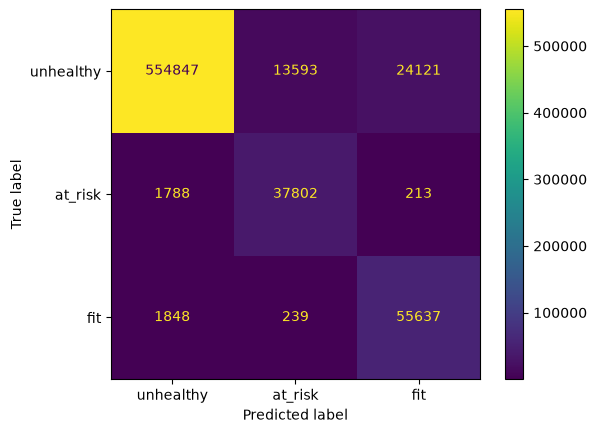

In [ ]:
y_pred=cross_val_predict(final_lgbm,X,y,cv=5,n_jobs=5)
ConfusionMatrixDisplay.from_predictions(y,y_pred,display_labels=['unhealthy','at_risk','fit']) #To see what kind of erros we have

In [ ]:
final_lgbm.fit(X,y) #We train the last model with optimal parameters

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('lgbm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](43,)","['sleep_duration','heart_rate','bmi',...,'sleep_cat', 'stress_x_sleep_deficit','sedentary_x_bmi']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,43
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ordinal_pipe', ...), ('cat_pipe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).B

In [ ]:
#We get the predicted probabilities for each of the 3 models
proba_lgbm = cross_val_predict(final_lgbm, X, y, cv=5, method='predict_proba', n_jobs=5)
proba_logi = cross_val_predict(logistic_pipe, X, y, cv=5, method='predict_proba', n_jobs=5)
proba_rf   = cross_val_predict(random_pipe, X, y, cv=5, method='predict_proba', n_jobs=5)

for w in [[5,1,1],[4,1,1],[3,1,1],[2,1,1],[1,1,1],[5,2,2],[4,2,2],[3,2,2]]:
    w = np.array(w) / sum(w)
    proba_ens = w[0]*proba_lgbm + w[1]*proba_logi + w[2]*proba_rf
    pred_ens = proba_ens.argmax(axis=1)
    score = balanced_accuracy_score(y, pred_ens)
    print(f'poids {w}, balanced_accuracy: {score}')

/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


poids [0.71428571 0.14285714 0.14285714], balanced_accuracy: 0.949809019977134
poids [0.66666667 0.16666667 0.16666667], balanced_accuracy: 0.9496985803062225
poids [0.6 0.2 0.2], balanced_accuracy: 0.9495617756320293
poids [0.5  0.25 0.25], balanced_accuracy: 0.9492603322788754
poids [0.33333333 0.33333333 0.33333333], balanced_accuracy: 0.9480815465382095
poids [0.55555556 0.22222222 0.22222222], balanced_accuracy: 0.9494592504916292
poids [0.5  0.25 0.25], balanced_accuracy: 0.9492603322788754
poids [0.42857143 0.28571429 0.28571429], balanced_accuracy: 0.9488245424254472


In [ ]:
#We want to find what are optiaml weights for ensembling
for w in [[20,1,1],[21,1,1],[22,1,1],[23,1,1],[24,1,1],[25,1,1],[26,1,1],[27,1,1]]:
    w = np.array(w) / sum(w)
    proba_ens = w[0]*proba_lgbm + w[1]*proba_logi + w[2]*proba_rf
    pred_ens = proba_ens.argmax(axis=1)
    score = balanced_accuracy_score(y, pred_ens)
    print(f'poids {w}, balanced_accuracy: {score}')

poids [0.90909091 0.04545455 0.04545455], balanced_accuracy: 0.9500046095248834
poids [0.91304348 0.04347826 0.04347826], balanced_accuracy: 0.9500077207862242
poids [0.91666667 0.04166667 0.04166667], balanced_accuracy: 0.9500119571075446
poids [0.92 0.04 0.04], balanced_accuracy: 0.9500104188232704
poids [0.92307692 0.03846154 0.03846154], balanced_accuracy: 0.9500180303245301
poids [0.92592593 0.03703704 0.03703704], balanced_accuracy: 0.9500245167658102
poids [0.92857143 0.03571429 0.03571429], balanced_accuracy: 0.9500172038759418
poids [0.93103448 0.03448276 0.03448276], balanced_accuracy: 0.9500138286960024


In [ ]:
df_test=features(df_test) #We apply features on df_test (it's stateless)

ens=VotingClassifier(estimators=[('final_lgbm',final_lgbm),('logistic_pipe',logistic_pipe),('random_pipe',random_pipe)],voting='soft',weights=[25,1,1])
ens.fit(X,y) #We fit on all the train dataset
predictions=ens.predict(df_test)

predictions_text = le.inverse_transform(predictions) #Invert transformer to be sure we do not make a mistake
soumission = pd.DataFrame({'id': test_ids, 'health_condition': predictions_text})

soumission.to_csv('soumission_ensembling_optimal.csv',index=False)

/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
final_lgbm = joblib.load('final_lgbm.pkl')
logistic_pipe = joblib.load('logistic_pipe.pkl')
random_pipe = joblib.load('random_pipe.pkl')
ens = joblib.load('ensemble.pkl')

In [ ]:
joblib.dump(final_lgbm, 'final_lgbm.pkl')       
joblib.dump(logistic_pipe, 'logistic_pipe.pkl') 
joblib.dump(random_pipe, 'random_pipe.pkl')   
joblib.dump(ens, 'ensemble.pkl')        

['ensemble.pkl']